<img src="https://raw.githubusercontent.com/CHoRUS-UF/notebooks/main/graphics/header.png" width="75%"/>

# **Deep Learning for Medical Imaging**
### Part II: Medical Image Segmentation
---

In this module, we will gain experience writing Python code to segment anatomical structures from medical images.

### **🚀 Let's get started.**

### Importing the Necessary Packages

In the following lines, we are importing all the required packages to run this notebook.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import cv2
from pathlib import Path
from glob import glob
import gdown, os, zipfile, shutil
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt


### Define several convenience functions.

In the following lines, we are creating some helper functions that we will reuse multiple times throughout the module.

In [2]:
smooth = 1e-15

### intersection of union (IOU)
### IOU = (Area of Overlap) / (Area of Union)
### 0 = no overlap, 1 = perfect overlap
def iou(y_true, y_pred):
    def f(y_true, y_pred):
        intersection = (y_true * y_pred).sum()
        union = y_true.sum() + y_pred.sum() - intersection
        x = (intersection + smooth) / (union + smooth)
        x = x.astype(np.float32)
        return x
    return tf.numpy_function(f, [y_true, y_pred], tf.float32)


### Dice coefficient (Dice)
### Dice = 2*(Area of Overlap)/(Area of A + Area of B)
### 0 = no overlap, 1 = perfect overlap
def dice_coef(y_true, y_pred):
    y_true = tf.keras.layers.Flatten()(y_true)
    y_pred = tf.keras.layers.Flatten()(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

### load the images and image masks for the training, validation, and testing
def load_data(path, split=0.1):
    images = sorted(glob(os.path.join(path, "images", "*.png")))
    masks = sorted(glob(os.path.join(path, "labels", "*.png")))
    split_size = int(len(images) * split)
    train_x, valid_x = train_test_split(images, test_size=split_size, random_state=42)
    train_y, valid_y = train_test_split(masks, test_size=split_size, random_state=42)
    train_x, test_x = train_test_split(train_x, test_size=split_size, random_state=42)
    train_y, test_y = train_test_split(train_y, test_size=split_size, random_state=42)
    return (train_x, train_y), (valid_x, valid_y), (test_x, test_y)

### read an image and resize to 256x256, rescale to [0,1]
def read_image(path):
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    x = cv2.resize(x, (256, 256))
    x = x/255.0
    x = x.astype(np.float32)
    x = np.expand_dims(x, axis=-1)
    return x

def read_mask(path):
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    x = cv2.resize(x, (256, 256))
    x = x/255.0
    x = x.astype(np.float32)
    x = np.expand_dims(x, axis=-1)
    return x

def tf_parse(x,y):
    def _parse(x, y):
        x = x.decode()
        y = y.decode()
        x = read_image(x)
        y = read_mask(y)
        return x, y
    x, y = tf.numpy_function(_parse, [x, y], [tf.float32, tf.float32])
    x.set_shape([256, 256, 1])
    y.set_shape([256, 256, 1])
    return x, y

def tf_dataset(X, Y, batch=8):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    dataset = dataset.shuffle(buffer_size=200)
    dataset = dataset.map(tf_parse)
    dataset = dataset.batch(batch)
    dataset = dataset.prefetch(4)
    return dataset

### Download the Preprocessed Dataset from Google Drive.

Click [this link](https://drive.google.com/uc?id=12es3pTH57EYU13GgYAp0YR8FQ4_62S-G) to download a preprocessed version of the target dataset.

### Define model and training parameters.
In the following lines, we are creating folders to save model and associate history, as well as defining key architecture and training parameters, such as learning rate, batch size, and number of epochs.

In [3]:
### path to image dataset
path = os.getcwd()+'/SmallestDataset/'

### image height and width
H = 256
W = 256

### path to save the model
model_path = path +  'Segmentation'

if os.path.isdir(model_path):
  print('Directory already exists...')
else:
  print('Directory does not exist; therefore, creating one...')
  os.mkdir(model_path)

### hyperparameters
batch_size = 16
lr = 1e-3
num_epochs = 10


Directory already exists...


### Compute Dataset Characteristics
In the following lines, we are printing how much images do we have for training, testing and validation.

In [4]:
(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_data(path)
print('There are {} train images.'.format(len(train_x)))
print('There are {} test images.'.format(len(test_x)))
print('There are {} validation images.'.format(len(valid_x)))

train_dataset = tf_dataset(train_x, train_y,  batch=batch_size)
valid_dataset = tf_dataset(valid_x, valid_y,  batch=batch_size)

There are 2400 train images.
There are 300 test images.
There are 300 validation images.
Metal device set to: Apple M1 Max


### Display a subset of images from the dataset.

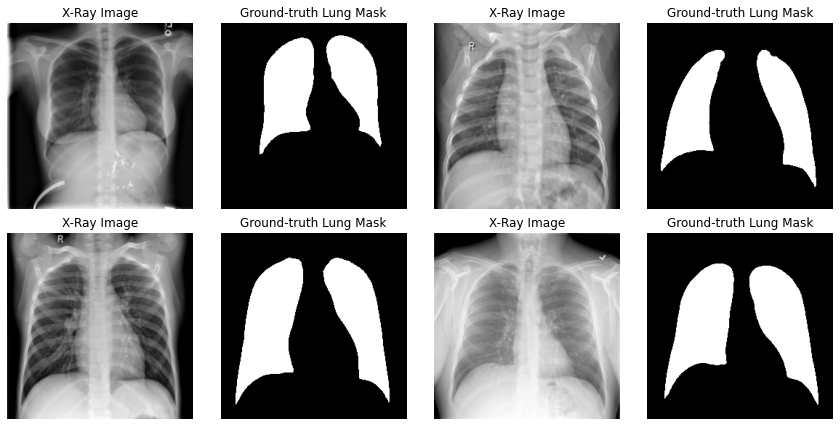

In [5]:
data = train_dataset.take(1)
count = 0
plt.figure(figsize = (12, 6))
for element in data:
    for i in range(0, 2):
        plt.subplot(2,4, count+1)
        plt.imshow(element[0][i,:,:,:], cmap = 'gray')
        plt.title('X-Ray Image')
        plt.axis('off')
        plt.subplot(2,4, count+2)
        plt.imshow(element[1][i,:,:,:], cmap = 'gray')
        plt.title('Ground-truth Lung Mask')
        plt.axis('off')
        plt.subplot(2,4, count+3)
        plt.imshow(element[0][i+3,:,:,:], cmap = 'gray')
        plt.title('X-Ray Image')
        plt.axis('off')
        plt.subplot(2,4, count+4)
        plt.imshow(element[1][i+3,:,:,:], cmap = 'gray')
        plt.title('Ground-truth Lung Mask')
        plt.axis('off')
        count+=4
    plt.tight_layout()
    # print(type(element[2]))

### Define the segmentation model.

We will use the popular UNET model for segmenation. The UNET architecture is a type of convolutional neural network (CNN) that is commonly used for image segmentation tasks. [It was introduced in 2015](https://arxiv.org/abs/1505.04597) by Olaf Ronneberger, Philipp Fischer, and Thomas Brox.

The UNET architecture is designed in a U-shape with an encoder-decoder architecture. The encoder part consists of several convolutional and max-pooling layers that progressively reduce the spatial resolution of the input image while extracting features. The decoder part consists of several up-convolutional and concatenation layers that progressively increase the spatial resolution of the features while decoding them back to the original image size.

The UNET architecture is particularly useful for image segmentation tasks because it allows for the precise localization of object boundaries in an image. The architecture is trained in a supervised manner using labeled data, where the input image is the image to be segmented, and the output is a pixel-wise segmentation mask that assigns each pixel to a particular class or category.

The UNET architecture is commonly used for medical image segmentation tasks, such as identifying tumors in medical images, as well as for other types of image segmentation tasks, such as segmenting objects in natural images. It has been shown to achieve state-of-the-art performance in many image segmentation benchmarks and is widely used in the research community.

<center>
    <figure>
        <img src="https://raw.githubusercontent.com/CHoRUS-UF/notebooks/main/graphics/unet.png" />
        <figcaption>
            <center>
                <a href="https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/">Image source.</a>
            </center>
        </figcaption>
    </figure>
</center>

In [6]:
def ConvBlock(input, num_filters):
    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same")(input)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    return x

def EncoderBlock(input, num_filters):
    x = ConvBlock(input, num_filters)
    p = tf.keras.layers.MaxPooling2D((2, 2))(x)
    return x, p

def DecoderBlock(input, skip_features, num_filters):
    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    x = tf.keras.layers.Concatenate()([x, skip_features])
    x = ConvBlock(x, num_filters)
    return x

def build_model(input_shape, start_num_filters):
    inputs = tf.keras.layers.Input(input_shape)

    s1, p1 = EncoderBlock(inputs, start_num_filters)
    s2, p2 = EncoderBlock(p1, 2*start_num_filters)
    s3, p3 = EncoderBlock(p2, 4*start_num_filters)
    s4, p4 = EncoderBlock(p3, 8*start_num_filters)

    b1 = ConvBlock(p4, 16*start_num_filters)

    d1 = DecoderBlock(b1, s4, start_num_filters)
    d2 = DecoderBlock(d1, s3, 2*start_num_filters)
    d3 = DecoderBlock(d2, s2, 4*start_num_filters)
    d4 = DecoderBlock(d3, s1, 8*start_num_filters)

    outputs = tf.keras.layers.Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = tf.keras.Model(inputs, outputs, name="U-Net")
    return model


input_shape = (256, 256, 1)
start_num_filters = 4

model = build_model(input_shape=input_shape, start_num_filters = start_num_filters)
model.summary()

Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 4)  40          ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 256, 256, 4)  16         ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                              

                                                                                                  
 conv2d_transpose (Conv2DTransp  (None, 32, 32, 4)   1028        ['activation_9[0][0]']           
 ose)                                                                                             
                                                                                                  
 concatenate (Concatenate)      (None, 32, 32, 36)   0           ['conv2d_transpose[0][0]',       
                                                                  'activation_7[0][0]']           
                                                                                                  
 conv2d_10 (Conv2D)             (None, 32, 32, 4)    1300        ['concatenate[0][0]']            
                                                                                                  
 batch_normalization_10 (BatchN  (None, 32, 32, 4)   16          ['conv2d_10[0][0]']              
 ormalizat

 batch_normalization_17 (BatchN  (None, 256, 256, 32  128        ['conv2d_17[0][0]']              
 ormalization)                  )                                                                 
                                                                                                  
 activation_17 (Activation)     (None, 256, 256, 32  0           ['batch_normalization_17[0][0]'] 
                                )                                                                 
                                                                                                  
 conv2d_18 (Conv2D)             (None, 256, 256, 1)  33          ['activation_17[0][0]']          
                                                                                                  
Total params: 108,353
Trainable params: 107,617
Non-trainable params: 736
__________________________________________________________________________________________________


In [7]:
metrics = [dice_coef, iou]
callbacks = [ModelCheckpoint(os.path.join(model_path, 'model.h5'), verbose=1, save_best_only=True),
             ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-7, verbose=1),
             CSVLogger(os.path.join(model_path, 'data.csv'))
            ]
model.compile(loss=dice_loss, optimizer=Adam(lr), metrics=metrics)

In [8]:
history = model.fit(train_dataset, epochs=num_epochs, validation_data=valid_dataset, callbacks=callbacks)

Epoch 1/10
150/150 [==============================] - ETA: 0s - loss: 0.1952 - dice_coef: 0.8048 - iou: 0.6964
Epoch 1: val_loss improved from inf to 0.52244, saving model to /Users/weishao/My Drive/InProcessing/University of Florida/Tutorials/AI Imaging for Medical Students/demo/SmallestDataset/Segmentation/model.h5
150/150 [==============================] - 28s 153ms/step - loss: 0.1952 - dice_coef: 0.8048 - iou: 0.6964 - val_loss: 0.5224 - val_dice_coef: 0.4768 - val_iou: 0.3138 - lr: 0.0010
Epoch 2/10
150/150 [==============================] - ETA: 0s - loss: 0.0463 - dice_coef: 0.9537 - iou: 0.9118
Epoch 2: val_loss improved from 0.52244 to 0.17444, saving model to /Users/weishao/My Drive/InProcessing/University of Florida/Tutorials/AI Imaging for Medical Students/demo/SmallestDataset/Segmentation/model.h5
150/150 [==============================] - 23s 151ms/step - loss: 0.0463 - dice_coef: 0.9537 - iou: 0.9118 - val_loss: 0.1744 - val_dice_coef: 0.8257 - val_iou: 0.7038 - lr: 0.0

### Visualize key performance metrics.
Let's display metrics for training and validation datasets.

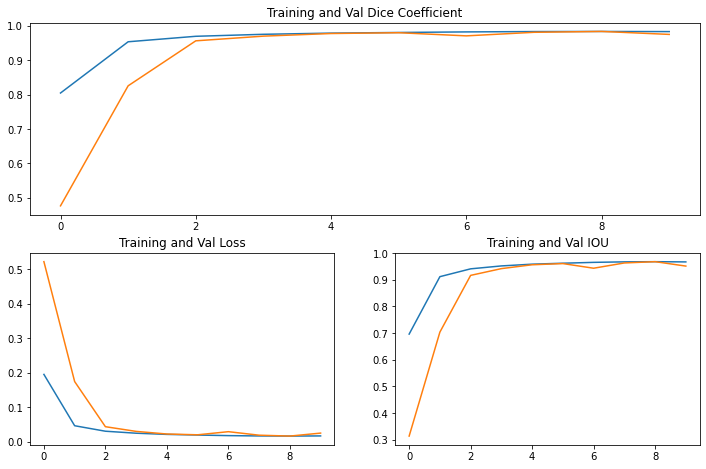

<Figure size 432x288 with 0 Axes>

In [9]:
def plot_result(history):
    plt.figure(figsize=(12, 12))
    plt.subplot(323)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Training and Val Loss')
    plt.subplot(324)
    plt.plot(history.history['iou'])
    plt.plot(history.history['val_iou'])
    plt.title('Training and Val IOU')
    plt.subplot(311)
    plt.plot(history.history['dice_coef'])
    plt.plot(history.history['val_dice_coef'])
    plt.title('Training and Val Dice Coefficient')
    plt.show()
    plt.tight_layout()
plot_result(history)

## Evaluate the generalization performance of our model on an unseen dataset of test images.

Let's check how our model is performing on test dataset. We can see that our model's performance is exceptionally good for testing dataset, which subsequently indicates that our model is ready to be used for realtime data.

In [10]:
test_dataset = tf_dataset(test_x, test_y,  batch=batch_size)
results = model.evaluate(test_dataset, batch_size=batch_size, verbose=1)

19/19 [==============================] - 1s 36ms/step - loss: 0.0275 - dice_coef: 0.9724 - iou: 0.9464


In [11]:
print('Dice Coefficient for Test Data: {}'.format(results[1]))
print('IOU for Test Data: {}'.format(results[2]))

Dice Coefficient for Test Data: 0.9724354147911072
IOU for Test Data: 0.9463894367218018


1/1 [==============================] - 1s 939ms/step


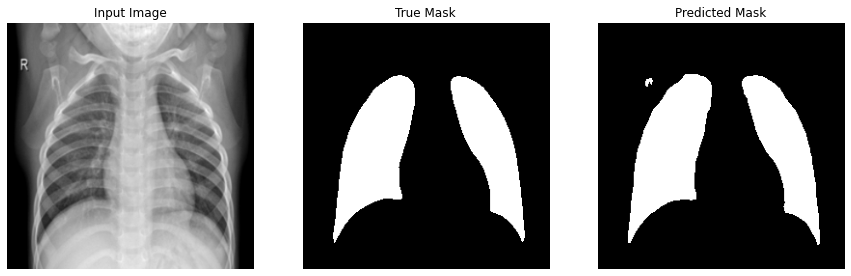

The Dice Coefficient for given image is 0.977870523929596
The IOU for given image is 0.9566991925239563.


In [12]:
# Let's select a random image from test data and see what our model predicts for it.
n = np.random.randint(0, len(test_x))
img_path = test_x[n]
mask_path = test_y[n]
img = read_image(img_path)
img = np.expand_dims(img, axis=0)
y_true = read_mask(mask_path)
y_pred = model.predict(img)[0]>0.5
y_pred = y_pred.astype(np.int32)

plt.figure(figsize = (15, 15))
plt.subplot(1,3,1)
plt.imshow(img[0], cmap = 'gray')
plt.title('Input Image')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(y_true, cmap = 'gray')
plt.title('True Mask')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(y_pred, cmap = 'gray')
plt.title('Predicted Mask')
plt.axis('off')
plt.show()

print('The Dice Coefficient for given image is {}'.format(dice_coef(y_true, y_pred.astype(np.float32))))
print('The IOU for given image is {}.'.format(iou(y_true, y_pred.astype(np.float32))))

---
> 🔗 This module is based on course material from Wei Shao, EEL6935 Deep Learning in Medical Image Analysis, Department of Electrical and Computer Engineering, University of Florida.
---